# EOS database demo (proof of concept)

## 1. Loading stuff

All the code (database class, routine to load data, routines to filter/manipulate data, and plotting routines) is hidden in the `./modules` folder.

In [1]:
from modules.eosdatabase import EOSDatabase

Read all the available thermo data. It will go through all sub-folders to find all files that end with `_thermo.dat`. It will also read the metadata contained in each corresponding `_thermo.toml` file, and it will load that data into the python object. The point is: **developpers add more files, users just need to give the path to the folder**.

In [2]:
db_thermo = EOSDatabase("./data")

Loaded: data/solomatovacaracas2021/solomatovacaracas2021_thermo.dat
Loaded: data/caracas2024/caracas2024_thermo.dat
Loaded: data/hakim2018/hakim2018_thermo.dat


## 2. Printing stuff

I created a little script to easily print the summary of the database that has been loaded. This script is entirely customisable by developpers. Again: **developpers add features, users access the data easily**.

In [3]:
db_thermo.summary()

EOSDatabase summary
-------------------
Rows   : 370
Columns: 18
-------------------
Caracas 2024 (NaCa2Al3Fe4Mg30Si24O65)
Hakim et al. 2018 (Fe)
Solomatova and Caracas 2021 (NaCa2Al3Fe4Mg30Si24O65)


*For developpers*: all the data is just a giant pandas dataframe. If you are more familiar with pandas dataframes, you can just use them instead.

In [4]:
import pandas as pd
dataframe = db_thermo.df
# print the available keys of the dataframe
print(dataframe.keys())
# print just the P-rho-T-citation info
print(dataframe[["P[GPa]","rho[g/cm^3]","T[K]","source_citation"]])

Index(['V[Angstroms^3]', 'rho[g/cm^3]', 'P[GPa]', 'Pst.dev.[GPa]', 'T[K]',
       'Tst.dev.[K]', 'source_unique_id', 'source_citation', 'source_year',
       'science_material', 'science_formula', 'science_phase',
       'science_method', 'data_delimiter', 'MDsteps', 'dP[GPa]', 'dT[K]',
       'U[kJ/kg]'],
      dtype='object')
            P[GPa]  rho[g/cm^3]     T[K]              source_citation
0        36.200000     4.040000  1994.22  Solomatova and Caracas 2021
1        19.420000     3.530000  1995.31  Solomatova and Caracas 2021
2         8.720000     3.110000  1994.66  Solomatova and Caracas 2021
3         3.110000     2.750000  1995.34  Solomatova and Caracas 2021
4        -0.420000     2.440000  1999.77  Solomatova and Caracas 2021
..             ...          ...      ...                          ...
365  121630.849640   105.886608   300.00            Hakim et al. 2018
366  125204.295132   107.177999   300.00            Hakim et al. 2018
367  128951.759158   108.501184   300.00

## 3. Manipulating the database

Here are a few "methods" (python routines) that I vibe-wrote to manipulate the database object. For example, one method prints all the species that exist in the table (material, formula, source).

In [5]:
db_thermo.print_species()

Species in database
-------------------

iron
  - Fe : Hakim et al. 2018

pyrolite
  - NaCa2Al3Fe4Mg30Si24O65 : Caracas 2024
  - NaCa2Al3Fe4Mg30Si24O65 : Solomatova and Caracas 2021


Supposedly we will have 500 different entries (500 papers) for 50 different materials, we only want to keep some of it. We have methods to isolate specific information. Here, I coded a script that filters the database in order to keep only things that contain "pyrolite" in the column "material". In the future, we (developpers) will add more user-friendly filters.

In [9]:
db_pyrolite = db_thermo.filter_out(
    field="science_material",
    contains="pyrolite",
)

db_pyrolite.print_species()

Species in database
-------------------

pyrolite
  - NaCa2Al3Fe4Mg30Si24O65 : Caracas 2024
  - NaCa2Al3Fe4Mg30Si24O65 : Solomatova and Caracas 2021


## 4. Outputs: plots and writing to file

Probably one of the most important features of this catalog: be able to write all the data into a file. Again, I went ahead and defined a script making it very easy to do.

In [10]:
db_pyrolite.export_tsv(filename="thermo_pyrolite")


Export complete
File: output/thermo_pyrolite_20260513.tsv
Rows exported: 191


And I also went a bit crazy and defined a method to do an easy plot: plot all the rho-P-T data, using unique combinations of point styles to distinguish sources.

Found 3 datasets


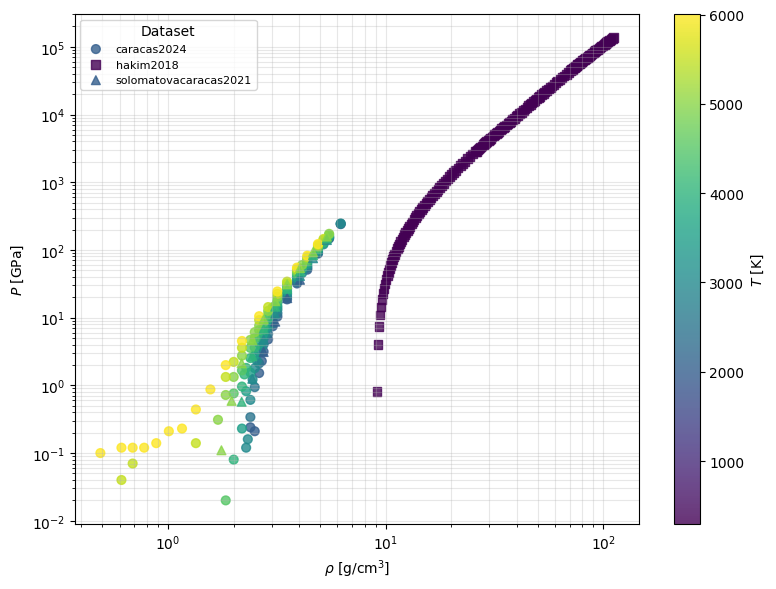

In [11]:
db_thermo.plot_rhopt()

Here I'm just playing around with the plot to make it look nicer. It's really powerful that the entire plot object is just passed to the main program and you can manipulate it however you want...

Found 3 datasets


(-50.0, 500.0)

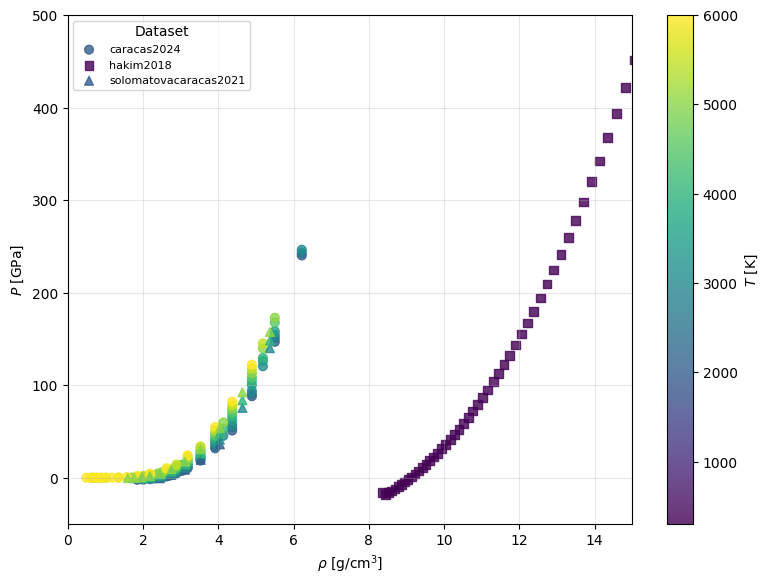

In [12]:
import matplotlib.pyplot as plt
db_thermo.plot_rhopt(plt_show=False)
plt.xscale('linear')
plt.yscale('linear')
plt.xlim(0,15)
plt.ylim(-50,500)